In [1]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

df = pd.read_csv(next(iter(uploaded)))

df.head()

Saving Mall_Customers.csv to Mall_Customers.csv


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
# Dataset information

df.shape

(10, 5)

In [3]:
df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              10 non-null     int64 
 1   Gender                  10 non-null     object
 2   Age                     10 non-null     int64 
 3   Annual Income (k$)      10 non-null     int64 
 4   Spending Score (1-100)  10 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 532.0+ bytes


,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,10.00000,10.000000,10.000000,10.000000
mean,5.50000,28.800000,17.000000,49.400000
std,3.02765,13.464356,1.490712,35.094159
min,1.00000,19.000000,15.000000,3.000000
25%,3.25000,21.250000,16.000000,14.250000
50%,5.50000,23.000000,17.000000,56.000000
75%,7.75000,30.750000,18.000000,76.750000
max,10.00000,64.000000,19.000000,94.000000


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

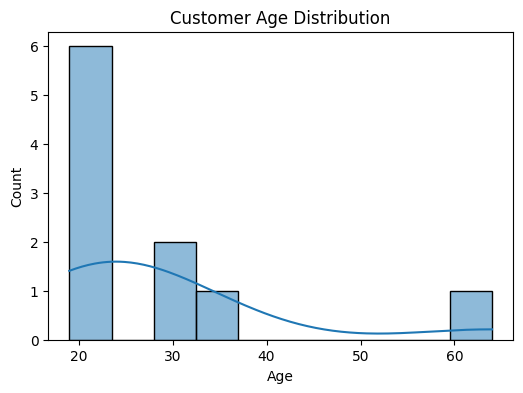

In [7]:
plt.figure(figsize=(6,4))

sns.histplot(df['Age'], bins=10, kde=True)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

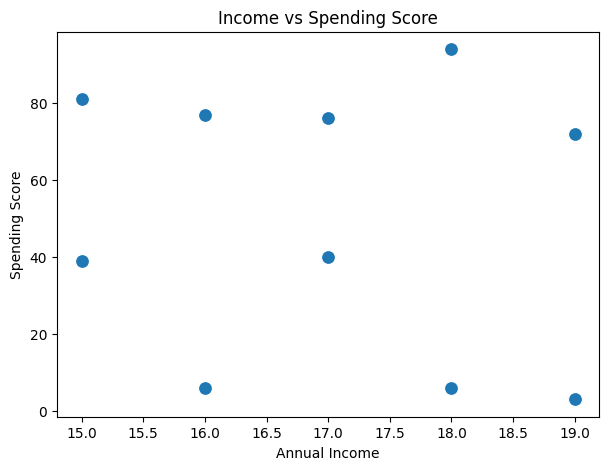

In [8]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df,
    s=100
)

plt.title("Income vs Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.show()

In [9]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.41421356, -0.3123757 ],
       [-1.41421356,  0.94914155],
       [-0.70710678, -1.30356783],
       [-0.70710678,  0.82899705],
       [ 0.        , -0.28233958]])

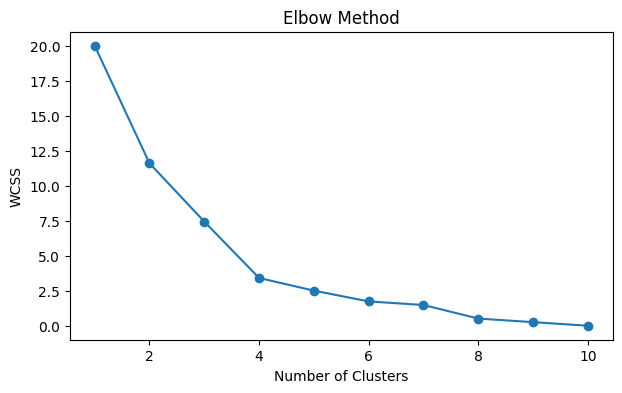

In [11]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7,4))

plt.plot(range(1, 11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [12]:
kmeans = KMeans(n_clusters=5, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,0
2,3,Female,20,16,6,2
3,4,Female,23,16,77,0
4,5,Female,31,17,40,2


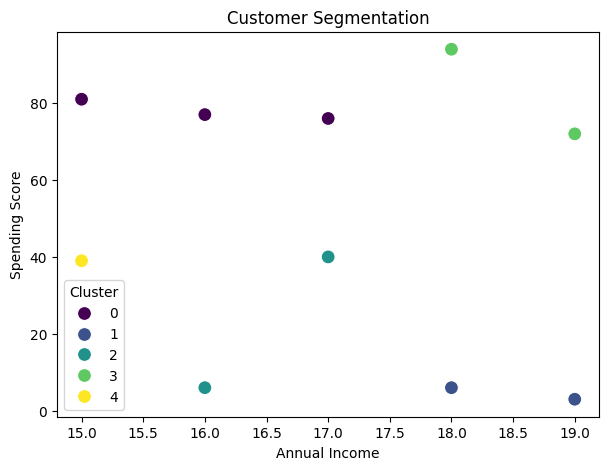

In [13]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=df,
    palette='viridis',
    s=100
)

plt.title("Customer Segmentation")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.show()

In [14]:
df['Cluster'].value_counts()

,count
Cluster,
0,3
1,2
2,2
3,2
4,1


In [15]:
df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,16.0,78.0
1,18.5,4.5
2,16.5,23.0
3,18.5,83.0
4,15.0,39.0


In [16]:
df['Segment'] = df['Cluster'].map({
    0: 'Average Customers',
    1: 'High Value Customers',
    2: 'Low Spending Customers',
    3: 'Target Customers',
    4: 'Premium Customers'
})

df[['CustomerID', 'Cluster', 'Segment']]

,CustomerID,Cluster,Segment
0,1,4,Premium Customers
1,2,0,Average Customers
2,3,2,Low Spending Customers
3,4,0,Average Customers
4,5,2,Low Spending Customers
5,6,0,Average Customers
6,7,1,High Value Customers
7,8,3,Target Customers
8,9,1,High Value Customers
9,10,3,Target Customers


In [17]:
cluster_summary = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

cluster_summary

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,16.0,78.0
1,18.5,4.5
2,16.5,23.0
3,18.5,83.0
4,15.0,39.0


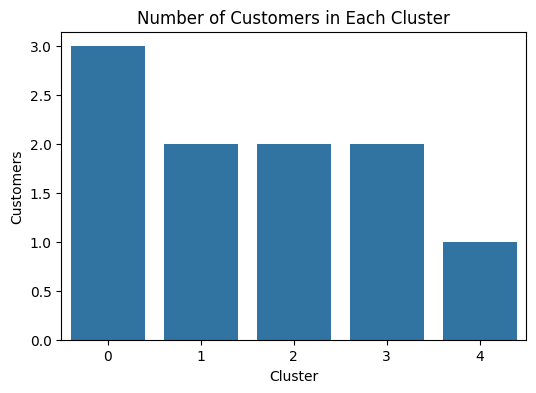

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(x='Cluster', data=df)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Customers")

plt.show()

## Marketing Insights

Cluster 0:
Average customers who can be encouraged through regular offers.

Cluster 1:
High value customers who should receive loyalty rewards.

Cluster 2:
Low spending customers who need personalized promotions.

Cluster 3:
Target customers with potential to increase spending.

Cluster 4:
Premium customers who should receive exclusive services.

# Conclusion

Customer segmentation was performed using the K-Means clustering algorithm.
Customers were divided into different groups based on annual income and spending behaviour.

The identified customer segments can help businesses:
- Target high-value customers with loyalty programs.
- Provide personalized offers to potential customers.
- Improve marketing strategies for low-engagement customers.

This analysis demonstrates how clustering techniques can support data-driven business decisions.